# Freight Rate Prediction

Predict `posted_rate` for loads in `train_test.csv`. Submit predictions for `validation.csv` and the December lane file.

## Install dependencies

In [6]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


## Imports and load data

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_DIR = Path("..").resolve() / "data"

train_df = pd.read_csv(DATA_DIR / "train_test.csv")
val_df = pd.read_csv(DATA_DIR / "validation.csv")
december_df = pd.read_csv(DATA_DIR / "december_chart_inputs.csv")
val_template_df = pd.read_csv(DATA_DIR / "validation_predictions_template.csv")

train_df.shape, val_df.shape, december_df.shape, val_template_df.shape

((48000, 14), (12000, 13), (31, 7), (12000, 2))

## Schema inspection

Compare train, validation, and December files side by side.

In [8]:
def schema_summary(df, name):
    rows = []
    for col in df.columns:
        if col == "load_id":
            role = "id"
        elif col == "posted_rate":
            role = "target"
        elif col == "predicted_rate":
            role = "output"
        else:
            role = "feature"

        rows.append({
            "dataset": name,
            "column": col,
            "dtype": str(df[col].dtype),
            "non_null": df[col].notna().sum(),
            "missing": df[col].isna().sum(),
            "role": role,
        })
    return pd.DataFrame(rows)

schema = pd.concat([
    schema_summary(train_df, "train"),
    schema_summary(val_df, "validation"),
    schema_summary(december_df, "december"),
], ignore_index=True)

schema

,dataset,column,dtype,non_null,missing,role
0,train,load_id,object,48000,0,id
1,train,pickup,object,48000,0,feature
2,train,delivery,object,48000,0,feature
3,train,pickup_lat,float64,48000,0,feature
4,train,pickup_lon,float64,48000,0,feature
5,train,delivery_lat,float64,48000,0,feature
6,train,delivery_lon,float64,48000,0,feature
7,train,distance,float64,48000,0,feature
8,train,equipment,object,48000,0,feature
9,train,weight,float64,47700,300,feature


In [9]:
print("Column sets")
print("train only:    ", sorted(set(train_df.columns) - set(val_df.columns)))
print("val only:      ", sorted(set(val_df.columns) - set(train_df.columns)))
print("december only: ", sorted(set(december_df.columns) - set(train_df.columns)))
print("missing from december vs train:", sorted(set(train_df.columns) - set(december_df.columns)))

print("\nload_id prefix")
print("train:", train_df["load_id"].str.split("-").str[0].value_counts().to_dict())
print("val:  ", val_df["load_id"].str.split("-").str[0].value_counts().to_dict())

numeric_cols = [
    "pickup_lat", "pickup_lon", "delivery_lat", "delivery_lon",
    "distance", "weight", "market_index", "quote_signal", "posted_rate",
]
categorical_cols = ["pickup", "delivery", "equipment", "date"]

print("\nnumeric:", numeric_cols)
print("categorical:", categorical_cols)

Column sets
train only:     ['posted_rate']
val only:       []
december only:  ['predicted_rate']
missing from december vs train: ['delivery_lat', 'delivery_lon', 'load_id', 'market_index', 'pickup_lat', 'pickup_lon', 'posted_rate', 'quote_signal']

load_id prefix
train: {'TR': 48000}
val:   {'TE': 12000}

numeric: ['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'weight', 'market_index', 'quote_signal', 'posted_rate']
categorical: ['pickup', 'delivery', 'equipment', 'date']


In [10]:
display(train_df.head(3))
display(val_df.head(3))
display(december_df.head(3))

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.0912,-76.7891,38.1691,-72.7456,274.3000,Dry Van,"30,658.0000",2025-01-01,0.9568,2.3960,645.4100
1,TR-000002,Richmond,Philadelphia,38.0912,-76.7891,39.2232,-72.9671,280.5000,Reefer,"17,555.0000",2025-01-01,0.9762,2.4335,679.9700
2,TR-000003,Philadelphia,Green Bay,39.2232,-72.9671,44.3030,-87.5287,967.8000,Dry Van,"31,721.0000",2025-01-01,1.0097,1.8449,"1,802.5400"


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal
0,TE-000001,Baton Rouge,Mobile,30.5013,-92.6537,31.8044,-88.2519,331.4000,Flatbed,"19,958.0000",2025-11-01,0.9040,1.8639
1,TE-000002,Savannah,Los Angeles,33.6097,-82.2999,28.5662,-116.7025,"2,406.2000",Reefer,"34,114.0000",2025-11-01,0.9285,1.8624
2,TE-000003,San Francisco,Raleigh,35.1967,-121.6985,35.3738,-77.4761,"2,846.6000",Dry Van,"33,435.0000",2025-11-01,0.8812,1.9548


,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,NaN
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,NaN
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,NaN


In [11]:
train_df.info()
print()
val_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype 

In [12]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
pickup_lat,"48,000.0000",35.6475,4.3153,28.3576,31.9869,35.2948,39.4110,44.3030
pickup_lon,"48,000.0000",-90.9290,13.4824,-121.6985,-98.4006,-88.0892,-83.2851,-69.5000
delivery_lat,"48,000.0000",35.6412,4.3172,28.3576,31.9869,35.2948,39.4110,44.3030
delivery_lon,"48,000.0000",-90.8573,13.4766,-121.6985,-98.4006,-87.5287,-83.2851,-69.5000
distance,"48,000.0000","1,135.8567",728.5644,70.0000,550.4000,953.3000,"1,645.5250","3,439.8000"
weight,"47,700.0000","31,028.8440","9,391.4406","-47,500.0000","25,800.0000","31,436.5000","37,018.0000","47,500.0000"
market_index,"47,626.0000",1.0834,0.1681,0.6764,0.9497,1.0558,1.2196,1.4678
quote_signal,"48,000.0000",2.0625,0.2914,0.6923,1.8910,2.0558,2.2217,3.6103
posted_rate,"48,000.0000","2,373.9807","1,486.4932",57.2200,"1,251.5550","2,030.7600","3,330.7500","25,533.0000"


**Observations**

- Train and validation share the same features; only train has `posted_rate`. Validation dates start Nov 2025 while train starts Jan 2025. Likely a time split.
- December file drops `load_id`, coords, and market signals. Same lane every row; only `date` changes.
- Missing: `weight` (300 train / 165 val), `market_index` (374 / 249).
- `date` is still a string. Parse before analysis.
- `posted_rate` is right-skewed (mean $2,374 vs median $2,031).
- Invalid weight values exist (min -47,500 lbs). Fix in data quality.

## Data quality

Check missing values, invalid ranges, duplicates, and date coverage on train and validation.

In [13]:
for df in [train_df, val_df, december_df]:
    df["date"] = pd.to_datetime(df["date"])


def quality_checks(df, name, has_target=False):
    rows = [{"dataset": name, "check": "rows", "value": len(df)}]

    if "load_id" in df.columns:
        rows.append({"dataset": name, "check": "duplicate load_id", "value": int(df["load_id"].duplicated().sum())})

    rows.append({"dataset": name, "check": "date min", "value": df["date"].min()})
    rows.append({"dataset": name, "check": "date max", "value": df["date"].max()})
    rows.append({"dataset": name, "check": "missing weight", "value": int(df["weight"].isna().sum())})

    if "market_index" in df.columns:
        rows.append({"dataset": name, "check": "missing market_index", "value": int(df["market_index"].isna().sum())})

    rows.append({"dataset": name, "check": "distance <= 0", "value": int((df["distance"] <= 0).sum())})
    rows.append({"dataset": name, "check": "weight < 0", "value": int((df["weight"] < 0).sum())})

    if has_target:
        rows.append({"dataset": name, "check": "posted_rate <= 0", "value": int((df["posted_rate"] <= 0).sum())})

    if "pickup_lat" in df.columns:
        lat_bad = ((df["pickup_lat"] < 24) | (df["pickup_lat"] > 50) |
                   (df["delivery_lat"] < 24) | (df["delivery_lat"] > 50)).sum()
        rows.append({"dataset": name, "check": "lat outside 24-50", "value": int(lat_bad)})

    rows.append({"dataset": name, "check": "equipment types", "value": ", ".join(sorted(df["equipment"].unique()))})
    return rows


report = pd.DataFrame(
    quality_checks(train_df, "train", has_target=True)
    + quality_checks(val_df, "validation")
)
report

,dataset,check,value
0,train,rows,48000
1,train,duplicate load_id,0
2,train,date min,2025-01-01 00:00:00
3,train,date max,2025-10-31 00:00:00
4,train,missing weight,300
5,train,missing market_index,374
6,train,distance <= 0,0
7,train,weight < 0,292
8,train,posted_rate <= 0,0
9,train,lat outside 24-50,0


In [14]:
invalid_weight = train_df[train_df["weight"] < 0][["load_id", "pickup", "delivery", "equipment", "weight", "posted_rate"]]
print(f"Negative weight rows in train: {len(invalid_weight)}")
display(invalid_weight.head(10))

invalid_weight_val = val_df[val_df["weight"] < 0][["load_id", "pickup", "delivery", "equipment", "weight"]]
print(f"\nNegative weight rows in validation: {len(invalid_weight_val)}")

Negative weight rows in train: 292


,load_id,pickup,delivery,equipment,weight,posted_rate
68,TR-000069,Amarillo,Dayton,Reefer,"-36,559.0000","2,831.2700"
204,TR-000205,Fresno,Tucson,Dry Van,"-26,670.0000","1,046.9200"
206,TR-000207,Columbia,Raleigh,Reefer,"-20,003.0000",959.1500
225,TR-000226,Greensboro,Lubbock,Reefer,"-23,981.0000","2,836.0000"
376,TR-000377,Madison,Providence,Dry Van,"-41,397.0000","2,522.5400"
446,TR-000447,Albuquerque,Albany,Reefer,"-37,215.0000","4,841.5700"
495,TR-000496,Montgomery,Dayton,Dry Van,"-31,214.0000","1,473.7800"
641,TR-000642,Tulsa,Indianapolis,Dry Van,"-41,023.0000","1,264.3300"
806,TR-000807,Cincinnati,Buffalo,Dry Van,"-28,320.0000","1,307.7600"
1093,TR-001094,Cincinnati,Albany,Dry Van,"-25,153.0000","1,907.8300"



Negative weight rows in validation: 145


**Observations**

- Dates parsed. Train: Jan–Oct 2025. Validation: Nov–Dec 2025. No overlap.
- No duplicate `load_id` values. Equipment is always Dry Van, Reefer, or Flatbed.
- No zero/negative distance or `posted_rate` in train. Coordinates sit within expected US lat range.
- `weight` issues: missing rows plus negative values (292 train, 145 val). Treat negatives as bad data, not missing.
- `market_index` missing in 374 train / 249 val rows. `quote_signal` is complete.
- Plan: flag `weight_missing`, impute negative/missing weight by equipment median; flag `market_index_missing`, impute by month median.

## Univariate EDA

Distribution of each column on the training set.

mean         2,373.9807
median       2,030.7600
skew             1.9024
rpm_mean         2.2153
rpm_median       2.1453
rpm_skew         8.7203
dtype: float64

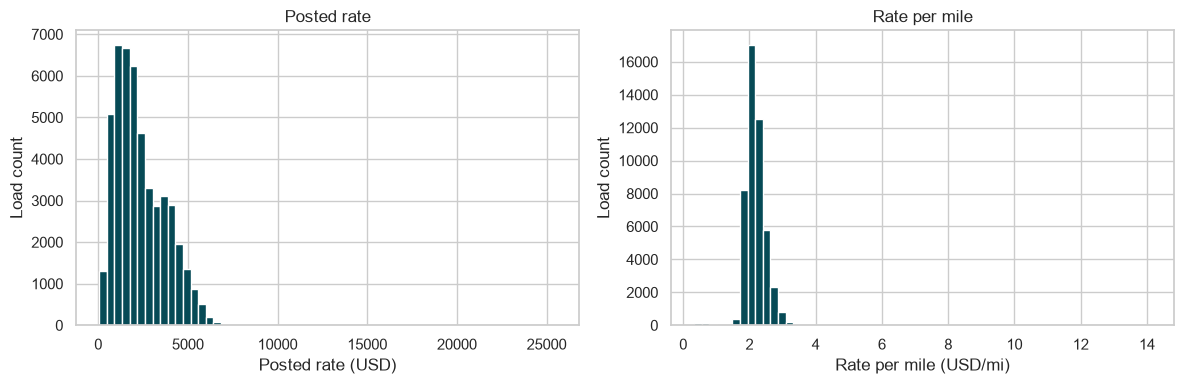

In [15]:
train_df["rate_per_mile"] = train_df["posted_rate"] / train_df["distance"]

target_stats = pd.Series({
    "mean": train_df["posted_rate"].mean(),
    "median": train_df["posted_rate"].median(),
    "skew": train_df["posted_rate"].skew(),
    "rpm_mean": train_df["rate_per_mile"].mean(),
    "rpm_median": train_df["rate_per_mile"].median(),
    "rpm_skew": train_df["rate_per_mile"].skew(),
})
display(target_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_df["posted_rate"], bins=60, color="#064A56", edgecolor="white")
axes[0].set_title("Posted rate")
axes[0].set_xlabel("Posted rate (USD)")
axes[0].set_ylabel("Load count")

axes[1].hist(train_df["rate_per_mile"], bins=60, color="#064A56", edgecolor="white")
axes[1].set_title("Rate per mile")
axes[1].set_xlabel("Rate per mile (USD/mi)")
axes[1].set_ylabel("Load count")
plt.tight_layout()
plt.show()

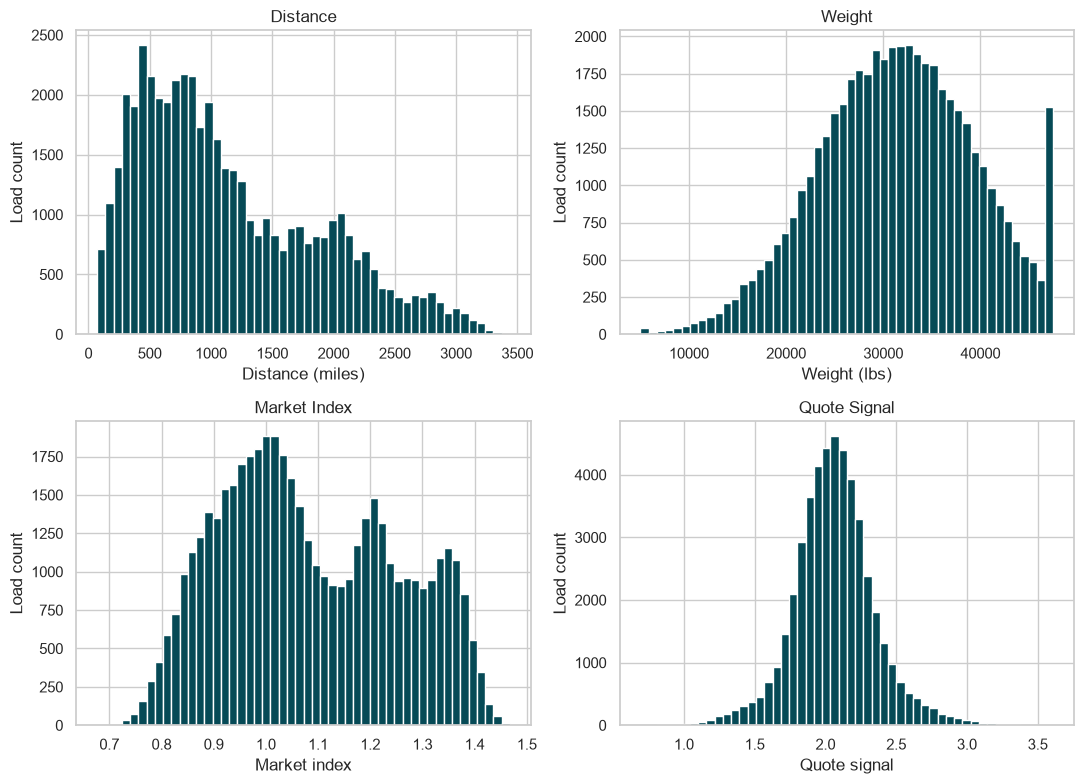

In [16]:
numeric_features = ["distance", "weight", "market_index", "quote_signal"]
feature_labels = {
    "distance": "Distance (miles)",
    "weight": "Weight (lbs)",
    "market_index": "Market index",
    "quote_signal": "Quote signal",
}
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, col in zip(axes.ravel(), numeric_features):
    data = train_df[col].dropna()
    if col == "weight":
        data = data[data > 0]
    ax.hist(data, bins=50, color="#064A56", edgecolor="white")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel(feature_labels[col])
    ax.set_ylabel("Load count")

plt.tight_layout()
plt.show()

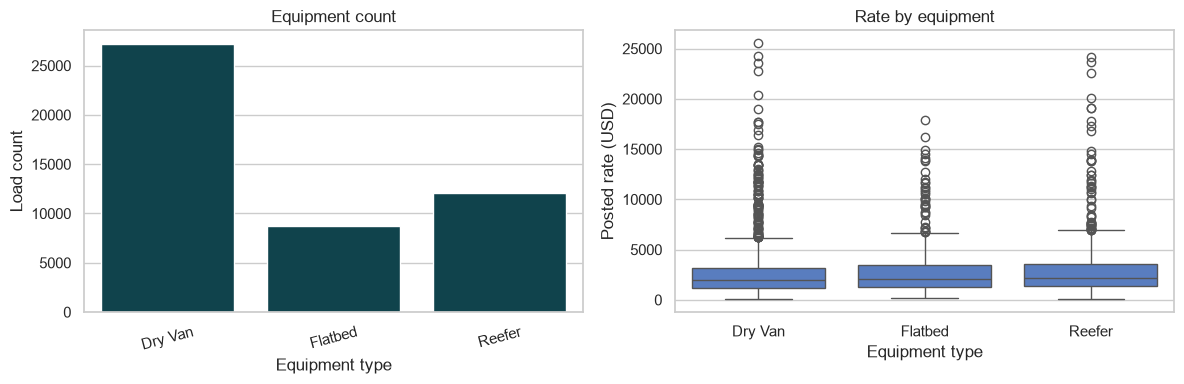

,count,mean,median
equipment,,,
Dry Van,27202,"2,272.0000","1,953.0000"
Flatbed,8753,"2,445.0000","2,077.0000"
Reefer,12045,"2,554.0000","2,197.0000"


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=train_df, x="equipment", order=["Dry Van", "Flatbed", "Reefer"], ax=axes[0], color="#064A56")
axes[0].set_title("Equipment count")
axes[0].set_xlabel("Equipment type")
axes[0].set_ylabel("Load count")
axes[0].tick_params(axis="x", rotation=15)

sns.boxplot(data=train_df, x="equipment", y="posted_rate", order=["Dry Van", "Flatbed", "Reefer"], ax=axes[1])
axes[1].set_title("Rate by equipment")
axes[1].set_xlabel("Equipment type")
axes[1].set_ylabel("Posted rate (USD)")
plt.tight_layout()
plt.show()

train_df.groupby("equipment")["posted_rate"].agg(["count", "mean", "median"]).round(0)

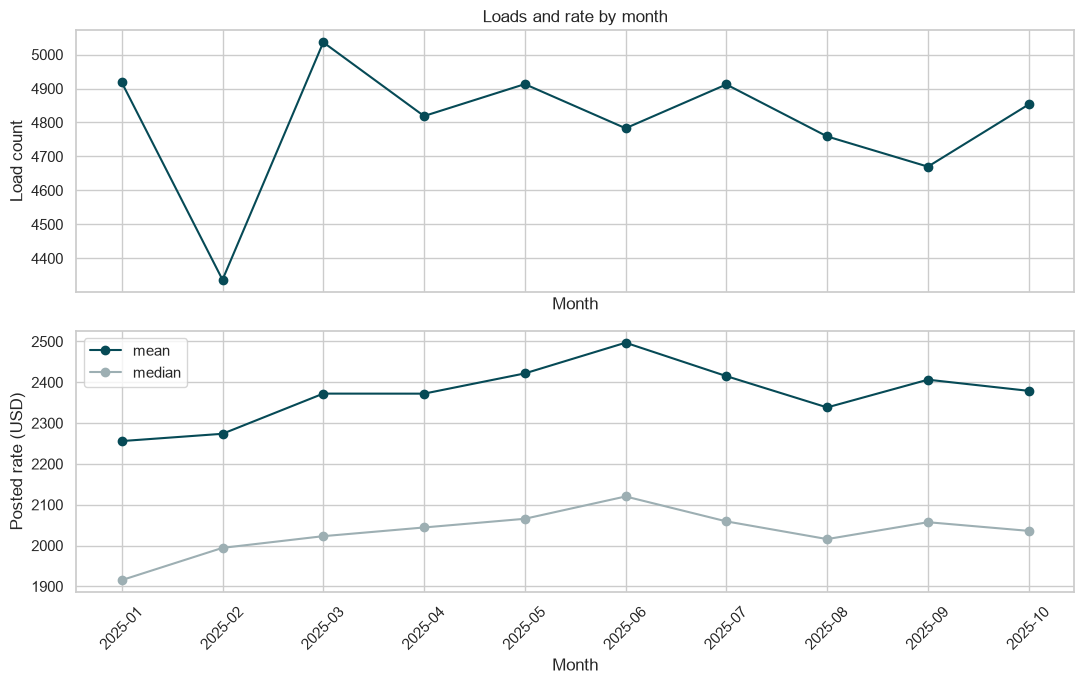

,loads,mean_rate,median_rate
date,,,
2025-01,4918,"2,256.0000","1,915.0000"
2025-02,4337,"2,274.0000","1,994.0000"
2025-03,5036,"2,372.0000","2,023.0000"
2025-04,4819,"2,372.0000","2,044.0000"
2025-05,4913,"2,422.0000","2,066.0000"
2025-06,4783,"2,497.0000","2,120.0000"
2025-07,4912,"2,415.0000","2,059.0000"
2025-08,4759,"2,338.0000","2,016.0000"
2025-09,4670,"2,406.0000","2,057.0000"


In [18]:
monthly = train_df.groupby(train_df["date"].dt.to_period("M")).agg(
    loads=("load_id", "count"),
    mean_rate=("posted_rate", "mean"),
    median_rate=("posted_rate", "median"),
)
monthly.index = monthly.index.astype(str)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(monthly.index, monthly["loads"], marker="o", color="#064A56")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Load count")
axes[0].set_title("Loads and rate by month")

axes[1].plot(monthly.index, monthly["mean_rate"], marker="o", label="mean", color="#064A56")
axes[1].plot(monthly.index, monthly["median_rate"], marker="o", label="median", color="#9DAFB3")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Posted rate (USD)")
axes[1].legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly.round(0)

Unique pickup cities: 64
Unique delivery cities: 64


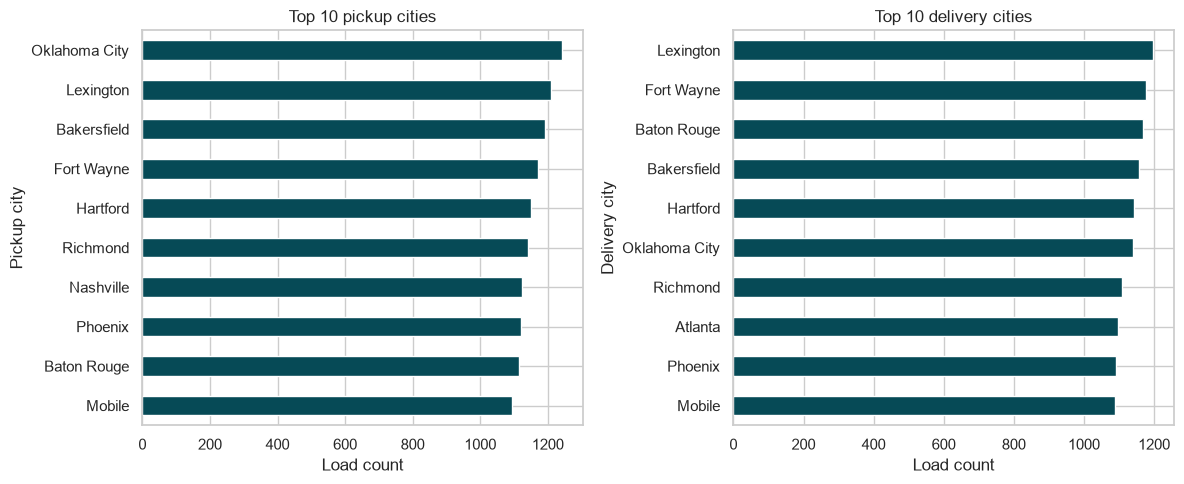

In [19]:
print(f"Unique pickup cities: {train_df['pickup'].nunique()}")
print(f"Unique delivery cities: {train_df['delivery'].nunique()}")

top_pickup = train_df["pickup"].value_counts().head(10)
top_delivery = train_df["delivery"].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
top_pickup.plot(kind="barh", ax=axes[0], color="#064A56")
axes[0].set_title("Top 10 pickup cities")
axes[0].set_xlabel("Load count")
axes[0].set_ylabel("Pickup city")
axes[0].invert_yaxis()

top_delivery.plot(kind="barh", ax=axes[1], color="#064A56")
axes[1].set_title("Top 10 delivery cities")
axes[1].set_xlabel("Load count")
axes[1].set_ylabel("Delivery city")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

**Observations**

- `posted_rate` is right-skewed (skew ~1.9). Mean ($2,374) sits above median ($2,031). Log transform worth testing.
- `rate_per_mile` is even more skewed. Useful for analysis, not as a model input (target leakage).
- Equipment order by median rate: Reefer > Flatbed > Dry Van. Dry Van is the most common type.
- Load volume is steady at ~4.7k–5k per month. Average rate peaks around June 2025, lowest in January.
- 64 pickup and 64 delivery cities. Volume is spread across markets; Oklahoma City, Lexington, Bakersfield lead pickups.

## Bivariate EDA

How features relate to each other and to `posted_rate`.

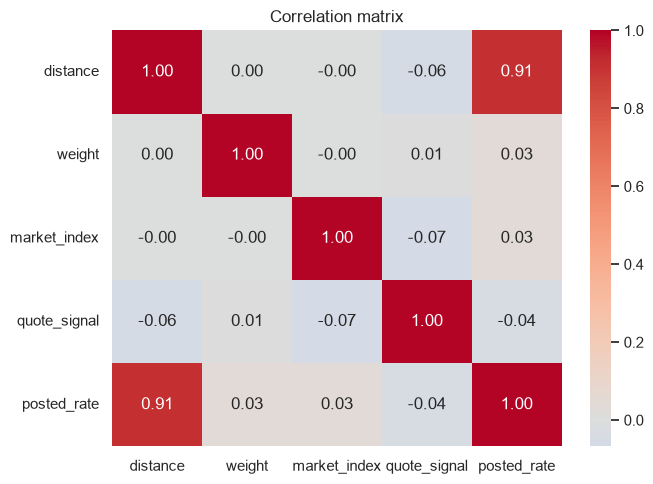

distance        0.9090
weight          0.0350
market_index    0.0340
quote_signal   -0.0400
Name: posted_rate, dtype: float64

In [20]:
corr_cols = ["distance", "weight", "market_index", "quote_signal", "posted_rate"]
corr = train_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

corr["posted_rate"].drop("posted_rate").round(3)

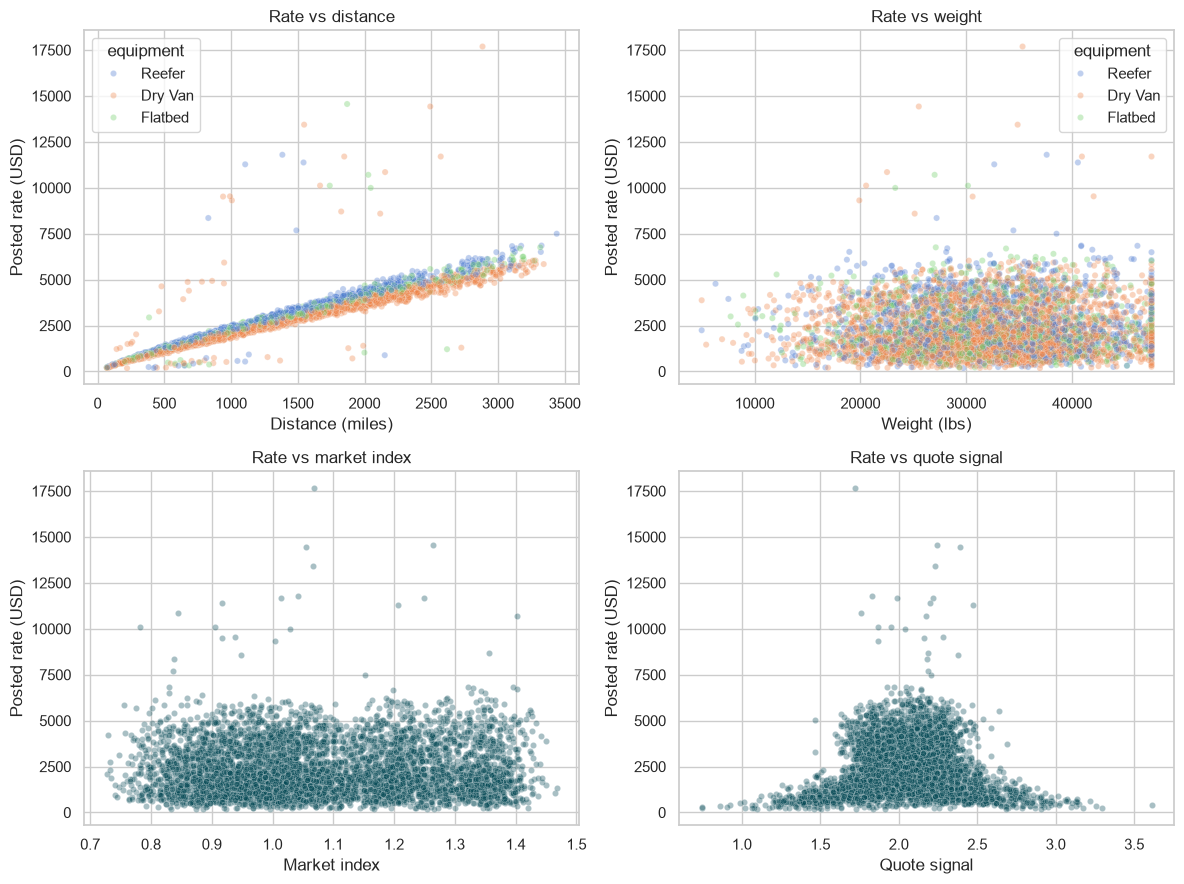

In [21]:
sample = train_df.sample(5_000, random_state=RANDOM_STATE)
weight_df = sample[sample["weight"] > 0]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.scatterplot(
    data=sample, x="distance", y="posted_rate", hue="equipment",
    alpha=0.35, s=20, ax=axes[0, 0],
)
axes[0, 0].set_xlabel("Distance (miles)")
axes[0, 0].set_ylabel("Posted rate (USD)")
axes[0, 0].set_title("Rate vs distance")

sns.scatterplot(
    data=weight_df, x="weight", y="posted_rate", hue="equipment",
    alpha=0.35, s=20, ax=axes[0, 1],
)
axes[0, 1].set_xlabel("Weight (lbs)")
axes[0, 1].set_ylabel("Posted rate (USD)")
axes[0, 1].set_title("Rate vs weight")

sns.scatterplot(
    data=sample, x="market_index", y="posted_rate",
    alpha=0.35, s=20, color="#064A56", ax=axes[1, 0],
)
axes[1, 0].set_xlabel("Market index")
axes[1, 0].set_ylabel("Posted rate (USD)")
axes[1, 0].set_title("Rate vs market index")

sns.scatterplot(
    data=sample, x="quote_signal", y="posted_rate",
    alpha=0.35, s=20, color="#064A56", ax=axes[1, 1],
)
axes[1, 1].set_xlabel("Quote signal")
axes[1, 1].set_ylabel("Posted rate (USD)")
axes[1, 1].set_title("Rate vs quote signal")

plt.tight_layout()
plt.show()

City pairs with more than one distance value: 3944 of 4014


,,loads,unique_distances,std
pickup,delivery,,,
Fort Wayne,Philadelphia,38,38,14.0487
Columbia,Oklahoma City,39,37,16.4849
Lexington,Kansas City,37,37,10.7915
Richmond,Oklahoma City,37,37,22.0634
Shreveport,Hartford,37,37,24.6600
Phoenix,Shreveport,39,37,20.0818
Lexington,Atlanta,39,37,9.9231
Richmond,Phoenix,37,36,41.4373
Mobile,Phoenix,36,36,31.0005


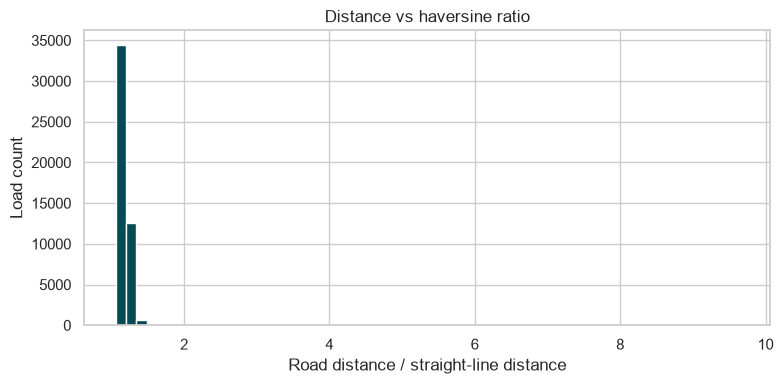

count   48,000.0000
mean         1.1950
std          0.1440
min          1.0580
25%          1.1650
50%          1.1820
75%          1.2050
max          9.6350
Name: road_to_straight_ratio, dtype: float64

In [22]:
from math import atan2, cos, radians, sin, sqrt


def haversine_miles(lat1, lon1, lat2, lon2):
    radius = 3958.8
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * radius * np.arctan2(np.sqrt(a), np.sqrt(1 - a))


train_df["haversine_miles"] = haversine_miles(
    train_df["pickup_lat"], train_df["pickup_lon"],
    train_df["delivery_lat"], train_df["delivery_lon"],
)
train_df["road_to_straight_ratio"] = train_df["distance"] / train_df["haversine_miles"]

pair_stats = train_df.groupby(["pickup", "delivery"])["distance"].agg(
    loads="count", unique_distances="nunique", std="std"
)
varying_pairs = pair_stats[pair_stats["unique_distances"] > 1].sort_values("unique_distances", ascending=False)

print(f"City pairs with more than one distance value: {len(varying_pairs)} of {len(pair_stats)}")
display(varying_pairs.head(10))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train_df["road_to_straight_ratio"], bins=60, color="#064A56", edgecolor="white")
ax.set_xlabel("Road distance / straight-line distance")
ax.set_ylabel("Load count")
ax.set_title("Distance vs haversine ratio")
plt.tight_layout()
plt.show()

train_df["road_to_straight_ratio"].describe().round(3)

Training rows matching December lane scenario: 16


,date,distance,weight,posted_rate
654,2025-01-05,358.3000,"22,567.0000",757.9300
1571,2025-01-10,358.2000,"31,556.0000",788.0800
2821,2025-01-18,362.1000,"27,842.0000",768.2200
3913,2025-01-25,357.5000,"37,102.0000",807.8900
8369,2025-02-23,355.1000,"27,601.0000",791.2500
10557,2025-03-08,359.9000,"24,178.0000",791.3100
11817,2025-03-16,367.6000,"16,195.0000",806.5400
12207,2025-03-19,363.1000,"27,600.0000",810.9600
14448,2025-04-01,362.8000,"25,383.0000",786.5000
15930,2025-04-11,360.5000,"40,999.0000",849.1700


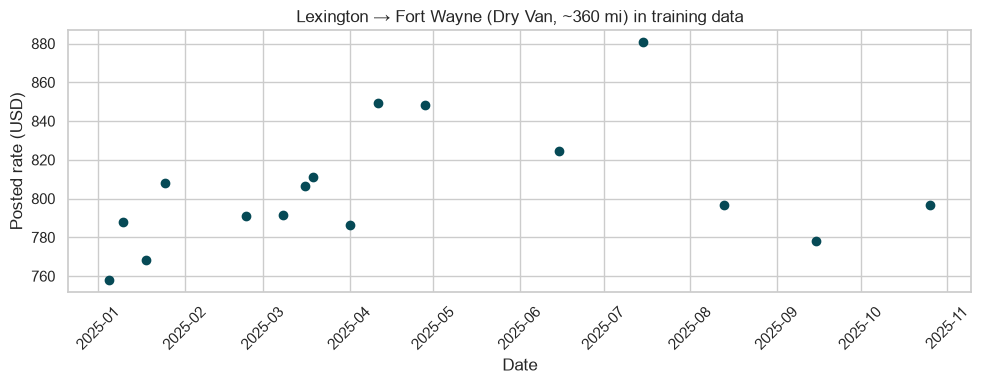

In [23]:
december_lane = train_df[
    (train_df["pickup"] == "Lexington")
    & (train_df["delivery"] == "Fort Wayne")
    & (train_df["equipment"] == "Dry Van")
    & (train_df["distance"].between(350, 370))
].copy()

print(f"Training rows matching December lane scenario: {len(december_lane)}")
display(december_lane[["date", "distance", "weight", "posted_rate"]].sort_values("date"))

if len(december_lane):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.scatter(december_lane["date"], december_lane["posted_rate"], color="#064A56")
    ax.set_xlabel("Date")
    ax.set_ylabel("Posted rate (USD)")
    ax.set_title("Lexington → Fort Wayne (Dry Van, ~360 mi) in training data")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

**Observations**

- `distance` drives most of the linear signal (corr ~0.91 with `posted_rate`). Weight and market signals are weak on their own.
- Rate vs distance trends up but spreads wide at every distance. Lane and equipment matter beyond miles alone.
- Most city pairs show multiple distance values despite fixed coordinates. Do not treat O-D as a proxy for distance.
- Road distance is typically ~1.18x straight-line miles. A small tail of extreme ratios exists.
- Only 16 training rows match the December chart lane closely. Use them as a sanity check, not as the main training signal.

## Validation strategy

Define how we split data for model development. The official holdout (`validation.csv`) is Nov–Dec 2025 and stays untouched until final predictions.

In [24]:
DEV_TRAIN_END = "2025-08-31"
DEV_VAL_START = "2025-09-01"
DEV_VAL_END = "2025-10-31"
HOLDOUT_START = "2025-11-01"

dev_train_df = train_df[train_df["date"] <= DEV_TRAIN_END].copy()
dev_val_df = train_df[(train_df["date"] >= DEV_VAL_START) & (train_df["date"] <= DEV_VAL_END)].copy()

split_summary = pd.DataFrame([
    {"split": "dev train", "source": "train_test.csv", "start": dev_train_df["date"].min(), "end": dev_train_df["date"].max(), "rows": len(dev_train_df)},
    {"split": "dev validation", "source": "train_test.csv", "start": dev_val_df["date"].min(), "end": dev_val_df["date"].max(), "rows": len(dev_val_df)},
    {"split": "holdout", "source": "validation.csv", "start": val_df["date"].min(), "end": val_df["date"].max(), "rows": len(val_df)},
])
split_summary

,split,source,start,end,rows
0,dev train,train_test.csv,2025-01-01,2025-08-31,38477
1,dev validation,train_test.csv,2025-09-01,2025-10-31,9523
2,holdout,validation.csv,2025-11-01,2025-12-31,12000


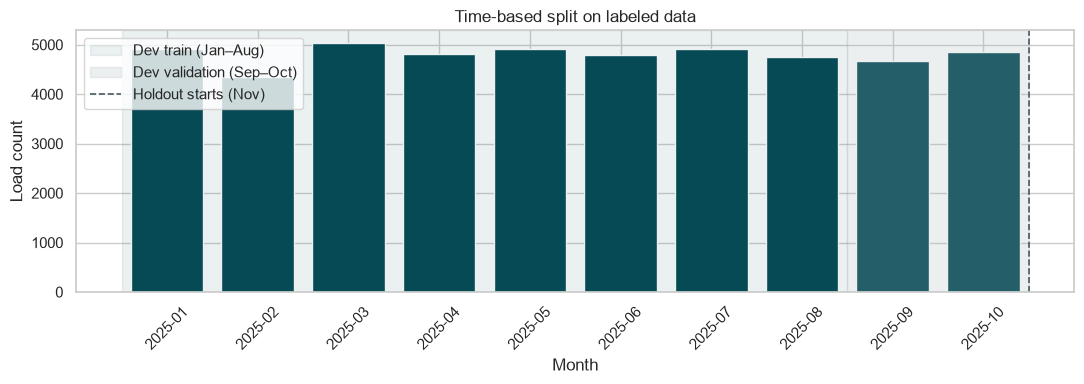

In [25]:
monthly_counts = train_df.groupby(train_df["date"].dt.to_period("M")).size()
monthly_counts.index = monthly_counts.index.astype(str)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(monthly_counts.index, monthly_counts.values, color="#064A56")
ax.axvspan(-0.5, 7.5, color="#064A56", alpha=0.08, label="Dev train (Jan–Aug)")
ax.axvspan(7.5, 9.5, color="#9DAFB3", alpha=0.20, label="Dev validation (Sep–Oct)")
ax.axvline(9.5, color="#455A60", linestyle="--", linewidth=1.2, label="Holdout starts (Nov)")
ax.set_xlabel("Month")
ax.set_ylabel("Load count")
ax.set_title("Time-based split on labeled data")
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

**Observations**

- `train_test.csv` covers Jan–Oct 2025. `validation.csv` covers Nov–Dec 2025. This is a forward-in-time prediction setup.
- Dev train: Jan–Aug (~38.5k rows). Dev validation: Sep–Oct (~9.5k rows). Use this for tuning and error analysis.
- Do not use random K-fold as the main validation story; it mixes future months into training and overstates performance.
- `validation.csv` stays untouched until the final model is chosen. Metrics on Sep–Oct guide decisions; Nov–Dec is the submission target.

## Feature engineering

Build a reusable feature function fit on dev train only. Same logic applies to dev validation, holdout, and December rows.

In [26]:
def fit_preprocessing_stats(dev_df, labeled_df):
    valid_weight = dev_df[dev_df["weight"] > 0]
    return {
        "weight_by_equipment": valid_weight.groupby("equipment")["weight"].median(),
        "market_by_month": labeled_df.groupby(labeled_df["date"].dt.month)["market_index"].median(),
        "market_index_median": labeled_df["market_index"].median(),
        "quote_signal_median": labeled_df["quote_signal"].median(),
        "pickup_coords": labeled_df.groupby("pickup")[["pickup_lat", "pickup_lon"]].first(),
        "delivery_coords": labeled_df.groupby("delivery")[["delivery_lat", "delivery_lon"]].first(),
    }


def enrich_raw_frame(df, stats):
    out = df.copy()
    if "pickup_lat" not in out.columns:
        out = out.join(stats["pickup_coords"], on="pickup")
    if "delivery_lat" not in out.columns:
        out = out.join(stats["delivery_coords"], on="delivery")
    if "market_index" not in out.columns:
        out["market_index"] = np.nan
    if "quote_signal" not in out.columns:
        out["quote_signal"] = np.nan
    if "date" not in out.columns or out["date"].dtype == "object":
        out["date"] = pd.to_datetime(out["date"])
    return out


def bearing_degrees(lat1, lon1, lat2, lon2):
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    return np.degrees(np.arctan2(x, y))


def engineer_features(df, stats):
    out = enrich_raw_frame(df, stats)

    out["weight_missing"] = out["weight"].isna() | (out["weight"] < 0)
    out.loc[out["weight"] < 0, "weight"] = np.nan
    out["weight"] = out["weight"].fillna(out["equipment"].map(stats["weight_by_equipment"]))

    out["market_index_missing"] = out["market_index"].isna().astype(int)
    out["market_index"] = out["market_index"].fillna(
        out["date"].dt.month.map(stats["market_by_month"])
    ).fillna(stats["market_index_median"])
    out["quote_signal"] = out["quote_signal"].fillna(stats["quote_signal_median"])

    out["month"] = out["date"].dt.month
    out["day_of_week"] = out["date"].dt.dayofweek
    out["is_weekend"] = out["day_of_week"].isin([5, 6]).astype(int)
    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)

    out["log_distance"] = np.log1p(out["distance"])
    out["log_weight"] = np.log1p(out["weight"])
    out["lane"] = out["pickup"] + " -> " + out["delivery"]

    out["mid_lat"] = (out["pickup_lat"] + out["delivery_lat"]) / 2
    out["mid_lon"] = (out["pickup_lon"] + out["delivery_lon"]) / 2
    out["bearing"] = bearing_degrees(
        out["pickup_lat"], out["pickup_lon"], out["delivery_lat"], out["delivery_lon"]
    )

    return out


feature_stats = fit_preprocessing_stats(dev_train_df, train_df)
feature_stats["market_by_month"].round(3)

date
1    0.9330
2    0.9930
3    1.0650
4    1.2070
5    1.3040
6    1.2750
7    1.2120
8    0.9820
9    0.8880
10   0.9580
Name: market_index, dtype: float64

In [27]:
feature_stats

{'weight_by_equipment': equipment
 Dry Van   31,418.0000
 Flatbed   31,511.0000
 Reefer    31,529.0000
 Name: weight, dtype: float64,
 'market_by_month': date
 1    0.9329
 2    0.9931
 3    1.0649
 4    1.2071
 5    1.3040
 6    1.2751
 7    1.2121
 8    0.9823
 9    0.8878
 10   0.9582
 Name: market_index, dtype: float64,
 'market_index_median': np.float64(1.0558),
 'quote_signal_median': np.float64(2.05575),
 'pickup_coords':              pickup_lat  pickup_lon
 pickup                             
 Albany          43.9697    -71.0584
 Albuquerque     35.3992   -109.5979
 Amarillo        33.1714   -104.3679
 Atlanta         34.8493    -86.2894
 Austin          29.3955    -99.6978
 ...                 ...         ...
 Tampa           28.3576    -86.9478
 Toledo          41.9766    -84.4590
 Tucson          30.9273   -113.2304
 Tulsa           33.4589    -94.7856
 Washington      38.8758    -77.0509
 
 [64 rows x 2 columns],
 'delivery_coords':              delivery_lat  delivery_lon
 

In [28]:
dev_train_feat = engineer_features(dev_train_df, feature_stats)
dev_val_feat = engineer_features(dev_val_df, feature_stats)
holdout_feat = engineer_features(val_df, feature_stats)
december_feat = engineer_features(december_df, feature_stats)

feature_cols = [
    "distance", "log_distance", "weight", "log_weight", "weight_missing",
    "market_index", "market_index_missing", "quote_signal",
    "pickup_lat", "pickup_lon", "delivery_lat", "delivery_lon",
    "mid_lat", "mid_lon", "bearing",
    "month", "day_of_week", "is_weekend", "month_sin", "month_cos",
    "equipment", "pickup", "delivery", "lane",
]

feature_cols_no_market = [
    col for col in feature_cols if col not in {"market_index", "quote_signal"}
]

pd.DataFrame({
    "dataset": ["dev train", "dev val", "holdout", "december"],
    "rows": [len(dev_train_feat), len(dev_val_feat), len(holdout_feat), len(december_feat)],
    "missing_weight_after": [
        dev_train_feat["weight"].isna().sum(),
        dev_val_feat["weight"].isna().sum(),
        holdout_feat["weight"].isna().sum(),
        december_feat["weight"].isna().sum(),
    ],
    "missing_market_after": [
        dev_train_feat["market_index"].isna().sum(),
        dev_val_feat["market_index"].isna().sum(),
        holdout_feat["market_index"].isna().sum(),
        december_feat["market_index"].isna().sum(),
    ],
})

,dataset,rows,missing_weight_after,missing_market_after
0,dev train,38477,0,0
1,dev val,9523,0,0
2,holdout,12000,0,0
3,december,31,0,0


In [29]:
display(dev_train_feat[feature_cols].head(3))
display(december_feat[feature_cols].head(3))

,distance,log_distance,weight,log_weight,weight_missing,market_index,market_index_missing,quote_signal,pickup_lat,pickup_lon,delivery_lat,delivery_lon,mid_lat,mid_lon,bearing,month,day_of_week,is_weekend,month_sin,month_cos,equipment,pickup,delivery,lane
0,274.3000,5.6179,"30,658.0000",10.3307,False,0.9568,0,2.3960,38.0912,-76.7891,38.1691,-72.7456,38.1302,-74.7673,87.3497,1,2,0,0.5000,0.8660,Dry Van,Richmond,Baltimore,Richmond -> Baltimore
1,280.5000,5.6401,"17,555.0000",9.7732,False,0.9762,0,2.4335,38.0912,-76.7891,39.2232,-72.9671,38.6572,-74.8781,68.0431,1,2,0,0.5000,0.8660,Reefer,Richmond,Philadelphia,Richmond -> Philadelphia
2,967.8000,6.8761,"31,721.0000",10.3648,False,1.0097,0,1.8449,39.2232,-72.9671,44.3030,-87.5287,41.7631,-80.2479,-60.1923,1,2,0,0.5000,0.8660,Dry Van,Philadelphia,Green Bay,Philadelphia -> Green Bay


,distance,log_distance,weight,log_weight,weight_missing,market_index,market_index_missing,quote_signal,pickup_lat,pickup_lon,delivery_lat,delivery_lon,mid_lat,mid_lon,bearing,month,day_of_week,is_weekend,month_sin,month_cos,equipment,pickup,delivery,lane
0,360,5.8889,"32,000.0000",10.3735,False,1.0558,1,2.0558,36.9915,-84.9988,41.3156,-85.3621,39.1536,-85.1804,-3.6138,12,0,0,-0.0000,1.0000,Dry Van,Lexington,Fort Wayne,Lexington -> Fort Wayne
1,360,5.8889,"32,000.0000",10.3735,False,1.0558,1,2.0558,36.9915,-84.9988,41.3156,-85.3621,39.1536,-85.1804,-3.6138,12,1,0,-0.0000,1.0000,Dry Van,Lexington,Fort Wayne,Lexington -> Fort Wayne
2,360,5.8889,"32,000.0000",10.3735,False,1.0558,1,2.0558,36.9915,-84.9988,41.3156,-85.3621,39.1536,-85.1804,-3.6138,12,2,0,-0.0000,1.0000,Dry Van,Lexington,Fort Wayne,Lexington -> Fort Wayne


**Observations**

- Weight stats from dev train (Jan–Aug). Market imputation stats from full labeled `train_df` (Jan–Oct), with overall median fallback.
- `market_index_missing` is set from raw missingness before imputation.
- Keep/drop `market_index` and `quote_signal` will be decided in baseline ablation (`feature_cols` vs `feature_cols_no_market`).
- December still gets imputed market values (month 12 falls back to global train median). Final December predictions may use validation Dec context at predict time.

## Baseline models

Train simple baselines on dev train (Jan–Aug), evaluate on dev validation (Sep–Oct). Compare full features vs no-market ablation.

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

CAT_COLS = ["equipment", "pickup", "delivery", "lane"]
TARGET = "posted_rate"


def regression_metrics(y_true, y_pred):
    y_pred = np.maximum(y_pred, 1)
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": mean_squared_error(y_true, y_pred) ** 0.5,
    }


def make_pipeline(feature_list, model, dense_output=False):
    num_cols = [col for col in feature_list if col not in CAT_COLS]
    preprocessor = ColumnTransformer(
        [
            ("num", SimpleImputer(strategy="median"), num_cols),
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore",
                    min_frequency=10,
                    sparse_output=not dense_output,
                ),
                CAT_COLS,
            ),
        ]
    )
    return Pipeline([("prep", preprocessor), ("model", model)])


def score_model(name, y_true, y_pred):
    metrics = regression_metrics(y_true, y_pred)
    return {"model": name, **metrics}


y_train = dev_train_feat[TARGET]
y_val = dev_val_feat[TARGET]

baseline_rows = []

equipment_median = dev_train_feat.groupby("equipment")[TARGET].median()
global_median = dev_train_feat[TARGET].median()
pred_equipment = dev_val_feat["equipment"].map(equipment_median).fillna(global_median)
baseline_rows.append(score_model("median by equipment", y_val, pred_equipment))

median_rpm = (dev_train_feat[TARGET] / dev_train_feat["distance"]).median()
pred_distance = dev_val_feat["distance"] * median_rpm
baseline_rows.append(score_model("distance x median rpm", y_val, pred_distance))

model_specs = [
    ("linear (full)", feature_cols, LinearRegression()),
    ("linear (no market)", feature_cols_no_market, LinearRegression()),
    (
        "random forest (full)",
        feature_cols,
        RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1,
            min_samples_leaf=5,
        ),
    ),
    (
        "random forest (no market)",
        feature_cols_no_market,
        RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1,
            min_samples_leaf=5,
        ),
    ),
]

for name, cols, estimator in model_specs:
    pipe = make_pipeline(cols, estimator)
    pipe.fit(dev_train_feat[cols], y_train)
    preds = pipe.predict(dev_val_feat[cols])
    baseline_rows.append(score_model(name, y_val, preds))

baseline_results = pd.DataFrame(baseline_rows).sort_values("mae").reset_index(drop=True)
baseline_results

,model,mae,rmse
0,random forest (full),134.2275,643.2373
1,random forest (no market),138.8985,644.2447
2,linear (full),170.7451,648.9222
3,linear (no market),177.2015,650.5858
4,distance x median rpm,256.9529,684.2479
5,median by equipment,"1,144.8785","1,561.5925"


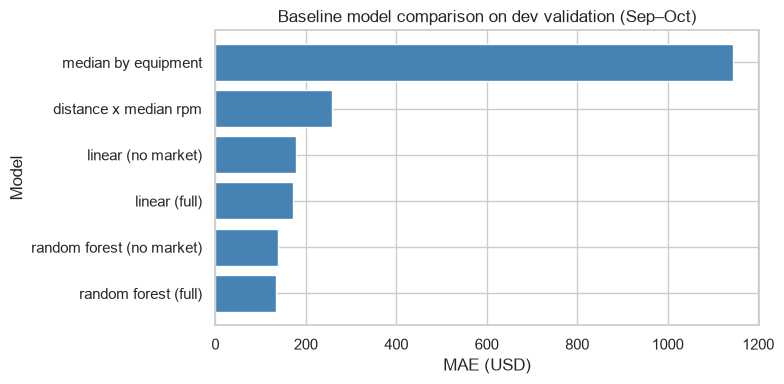

In [36]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = baseline_results.sort_values("mae", ascending=True)
ax.barh(plot_df["model"], plot_df["mae"], color="steelblue")
ax.set_xlabel("MAE (USD)")
ax.set_ylabel("Model")
ax.set_title("Baseline model comparison on dev validation (Sep–Oct)")
plt.tight_layout()
plt.show()

**Observations**

- **Random forest (full) wins** with MAE $134.23 and RMSE $643.24 on Sep–Oct dev validation.
- **Market features help modestly:** RF improves by ~$4.67 MAE (138.90 → 134.23); linear improves by ~$6.45 MAE (177.20 → 170.75). Keep `market_index`, `quote_signal`, and `market_index_missing`.
- **Trees beat linear regression** by ~$36 MAE — lane, geo, and time effects are non-linear; tree-based models are the right family for the final model.
- **Distance × median RPM** (MAE $256.95) confirms distance is the main driver but leaves a large gap to RF — multivariate features add real signal.
- **Median by equipment** (MAE $1,144.88) is a useless floor; equipment alone cannot explain rate variance without distance and lane context.
- **Next step:** tune a tree model (RF or gradient boosting) on `feature_cols`, using the same time-based split before holdout predictions.

## Dimensionality views (PCA / t-SNE)

Visualize structure in the scaled numeric feature space. Used for model-choice reasoning in the report and Loom — not as model inputs.

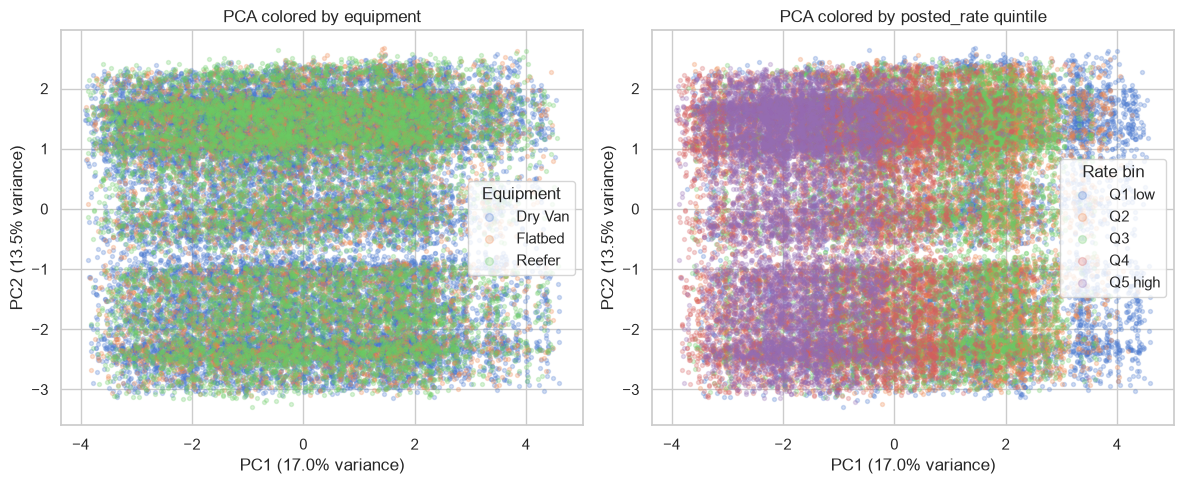

PC1   0.1704
PC2   0.1351
PC3   0.1084
PC4   0.0988
PC5   0.0923
Name: explained_variance_ratio, dtype: float64

In [37]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

numeric_viz_cols = [
    col for col in feature_cols if col not in {"equipment", "pickup", "delivery", "lane"}
]

viz_df = dev_train_feat[numeric_viz_cols + ["posted_rate", "equipment"]].copy()
viz_df["weight_missing"] = viz_df["weight_missing"].astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(viz_df[numeric_viz_cols])

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)

viz_df["rate_bin"] = pd.qcut(
    viz_df["posted_rate"],
    q=5,
    labels=["Q1 low", "Q2", "Q3", "Q4", "Q5 high"],
    duplicates="drop",
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for equipment in sorted(viz_df["equipment"].unique()):
    mask = viz_df["equipment"] == equipment
    axes[0].scatter(
        pca_coords[mask, 0],
        pca_coords[mask, 1],
        alpha=0.25,
        s=8,
        label=equipment,
    )
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
axes[0].set_title("PCA colored by equipment")
axes[0].legend(title="Equipment", markerscale=2)

for rate_bin in viz_df["rate_bin"].cat.categories:
    mask = viz_df["rate_bin"] == rate_bin
    axes[1].scatter(
        pca_coords[mask, 0],
        pca_coords[mask, 1],
        alpha=0.25,
        s=8,
        label=rate_bin,
    )
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
axes[1].set_title("PCA colored by posted_rate quintile")
axes[1].legend(title="Rate bin", markerscale=2)

plt.tight_layout()
plt.show()

pca_full = PCA(n_components=5, random_state=42).fit(X_scaled)
pd.Series(
    pca_full.explained_variance_ratio_,
    index=[f"PC{i + 1}" for i in range(5)],
    name="explained_variance_ratio",
).round(4)

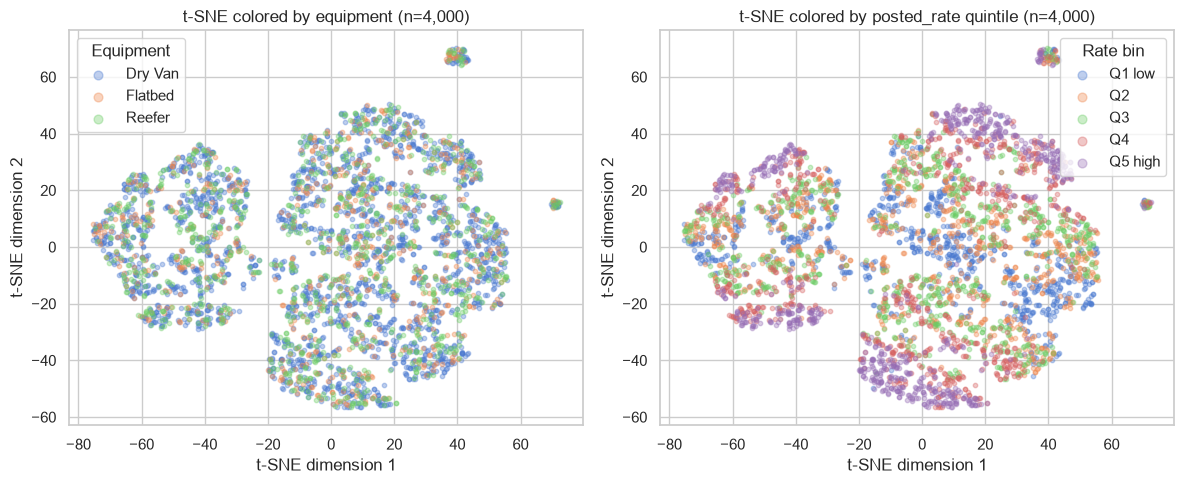

In [38]:
tsne_sample_n = 4000
tsne_df = viz_df.sample(n=tsne_sample_n, random_state=42)
X_tsne = scaler.transform(tsne_df[numeric_viz_cols])

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_coords = tsne.fit_transform(X_tsne)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for equipment in sorted(tsne_df["equipment"].unique()):
    mask = tsne_df["equipment"] == equipment
    axes[0].scatter(
        tsne_coords[mask, 0],
        tsne_coords[mask, 1],
        alpha=0.35,
        s=10,
        label=equipment,
    )
axes[0].set_xlabel("t-SNE dimension 1")
axes[0].set_ylabel("t-SNE dimension 2")
axes[0].set_title(f"t-SNE colored by equipment (n={tsne_sample_n:,})")
axes[0].legend(title="Equipment", markerscale=2)

for rate_bin in tsne_df["rate_bin"].cat.categories:
    mask = tsne_df["rate_bin"] == rate_bin
    axes[1].scatter(
        tsne_coords[mask, 0],
        tsne_coords[mask, 1],
        alpha=0.35,
        s=10,
        label=rate_bin,
    )
axes[1].set_xlabel("t-SNE dimension 1")
axes[1].set_ylabel("t-SNE dimension 2")
axes[1].set_title(f"t-SNE colored by posted_rate quintile (n={tsne_sample_n:,})")
axes[1].legend(title="Rate bin", markerscale=2)

plt.tight_layout()
plt.show()

**Observations**

- PC1 and PC2 capture only **17.0%** and **13.5%** of numeric feature variance (~**31% combined**). First five PCs reach ~**61%**. No single numeric axis summarizes the data — many factors (distance, geo, time, market) contribute in parallel.
- Equipment types **overlap heavily** in PCA space. Dry Van, Reefer, and Flatbed share the same cloud because this PCA uses numeric features only; equipment is not encoded here. Equipment effects show up once lane/categorical splits are added in tree models.
- Rate quintiles show **partial overlap with a weak gradient**, not clean separation. Low-rate and high-rate loads intermingle because numeric features alone (without lane identity) cannot fully separate price levels.
- **Takeaway for modeling:** overlapping PCA clouds + weak linear separability support the baseline finding that **tree models beat linear regression**. Rates are driven by complex, non-linear combinations — especially lane-specific effects that are not in this PCA view.
- **t-SNE** on 4,000 rows may show tighter local groupings than PCA, but it is for visualization and Loom narrative only — not fed into the model.

## Model selection and final training

Compare tuned tree models on dev validation (Sep–Oct), test log-target transform, then retrain the winner on all labeled data (Jan–Oct).

In [49]:
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingRegressor


def make_estimator(name):
    if name == "random forest":
        return RandomForestRegressor(
            n_estimators=200,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1,
        )
    if name == "hist gradient boosting":
        return HistGradientBoostingRegressor(
            max_depth=10,
            learning_rate=0.08,
            max_iter=250,
            random_state=42,
        )
    if name == "hist gradient boosting (deeper)":
        return HistGradientBoostingRegressor(
            max_depth=14,
            learning_rate=0.05,
            max_iter=350,
            random_state=42,
        )
    raise ValueError(f"Unknown model name: {name}")


MODEL_CANDIDATE_NAMES = [
    "random forest",
    "hist gradient boosting",
    "hist gradient boosting (deeper)",
]


def fit_predict_dollars(pipe, X_train, y_train, X_val, log_target=False):
    if log_target:
        y_fit = np.log1p(y_train)
        pipe.fit(X_train, y_fit)
        preds = np.expm1(pipe.predict(X_val))
    else:
        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_val)
    return np.maximum(preds, 1)


selection_rows = []
for name in MODEL_CANDIDATE_NAMES:
    for log_target in [False, True]:
        label = f"{name}{' (log target)' if log_target else ''}"
        pipe = make_pipeline(feature_cols, make_estimator(name), dense_output=True)
        preds = fit_predict_dollars(
            pipe,
            dev_train_feat[feature_cols],
            y_train,
            dev_val_feat[feature_cols],
            log_target=log_target,
        )
        selection_rows.append(score_model(label, y_val, preds))

model_selection_results = (
    pd.DataFrame(selection_rows).sort_values("mae").reset_index(drop=True)
)
model_selection_results

,model,mae,rmse
0,hist gradient boosting (log target),127.2153,639.3224
1,hist gradient boosting (deeper) (log target),129.8432,640.4773
2,hist gradient boosting (deeper),132.1861,637.5137
3,hist gradient boosting,133.7894,638.9872
4,random forest (log target),137.0591,644.3022
5,random forest,144.0180,651.1155


In [50]:
best_row = model_selection_results.iloc[0]
best_label = best_row["model"]
final_log_target = "(log target)" in best_label
best_name = best_label.replace(" (log target)", "")

best_estimator = make_estimator(best_name)

final_feature_stats = fit_preprocessing_stats(train_df, train_df)
train_full_feat = engineer_features(train_df, final_feature_stats)

final_model = make_pipeline(feature_cols, best_estimator, dense_output=True)
y_full = train_full_feat[TARGET]

if final_log_target:
    final_model.fit(train_full_feat[feature_cols], np.log1p(y_full))
else:
    final_model.fit(train_full_feat[feature_cols], y_full)


def predict_rate(model, feature_df, log_target=False):
    preds = model.predict(feature_df[feature_cols])
    if log_target:
        preds = np.expm1(preds)
    return np.maximum(preds, 1)


print(f"Selected model: {best_label}")
print(f"Dev validation MAE: ${best_row['mae']:.2f} | RMSE: ${best_row['rmse']:.2f}")
print(f"Retrained on {len(train_full_feat):,} labeled rows (Jan–Oct)")

Selected model: hist gradient boosting (log target)
Dev validation MAE: $127.22 | RMSE: $639.32
Retrained on 48,000 labeled rows (Jan–Oct)


**Observations**

- **Winner:** `hist gradient boosting (log target)` — MAE **$127.22**, RMSE **$639.32** on Sep–Oct dev validation (~$7 better than baseline RF at $134.23).
- **Log-target helps every family:** HGB 133.79 → 127.22; RF 144.02 → 137.06. Right-skewed `posted_rate` benefits from modeling `log1p(rate)` then reversing with `expm1`.
- **HGB beats RF** on every comparison here (all three HGB configs beat both RF configs); sequential boosting fits lane/interaction patterns better than bagged trees at this budget.
- **Final model** retrained on all **48,000** Jan–Oct rows using `final_feature_stats`. Holdout predictions use this refit in the submission section below.

## Error analysis

Inspect where the selected model fails on **unseen** Sep–Oct dev validation. Analysis model uses the same config as `final_model` but is trained on Jan–Aug only (not the full Jan–Oct refit).

In [51]:
analysis_model = make_pipeline(feature_cols, make_estimator(best_name), dense_output=True)
if final_log_target:
    analysis_model.fit(dev_train_feat[feature_cols], np.log1p(y_train))
else:
    analysis_model.fit(dev_train_feat[feature_cols], y_train)

error_df = dev_val_feat.copy()
error_df["predicted_rate"] = predict_rate(
    analysis_model, dev_val_feat, log_target=final_log_target
)
error_df["residual"] = error_df["posted_rate"] - error_df["predicted_rate"]
error_df["abs_error"] = error_df["residual"].abs()
error_df["pct_error"] = 100 * error_df["abs_error"] / error_df["posted_rate"]

pd.DataFrame([score_model("analysis model (Sep–Oct)", y_val, error_df["predicted_rate"])])

,model,mae,rmse
0,analysis model (Sep–Oct),127.2153,639.3224


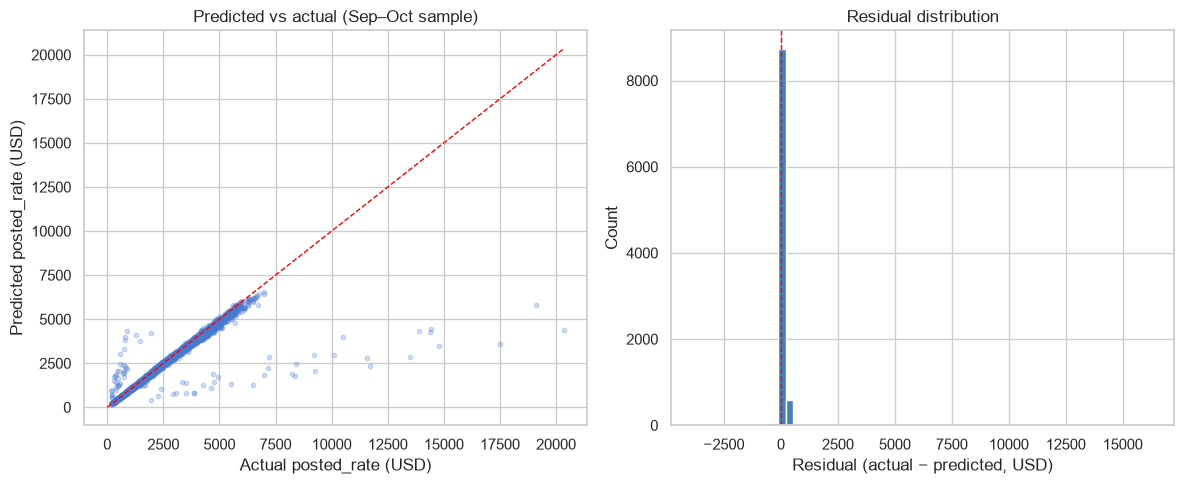

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sample = error_df.sample(n=min(5000, len(error_df)), random_state=42)
axes[0].scatter(sample["posted_rate"], sample["predicted_rate"], alpha=0.25, s=10)
max_rate = max(sample["posted_rate"].max(), sample["predicted_rate"].max())
axes[0].plot([0, max_rate], [0, max_rate], color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Actual posted_rate (USD)")
axes[0].set_ylabel("Predicted posted_rate (USD)")
axes[0].set_title("Predicted vs actual (Sep–Oct sample)")

axes[1].hist(error_df["residual"], bins=60, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Residual (actual − predicted, USD)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution")

plt.tight_layout()
plt.show()

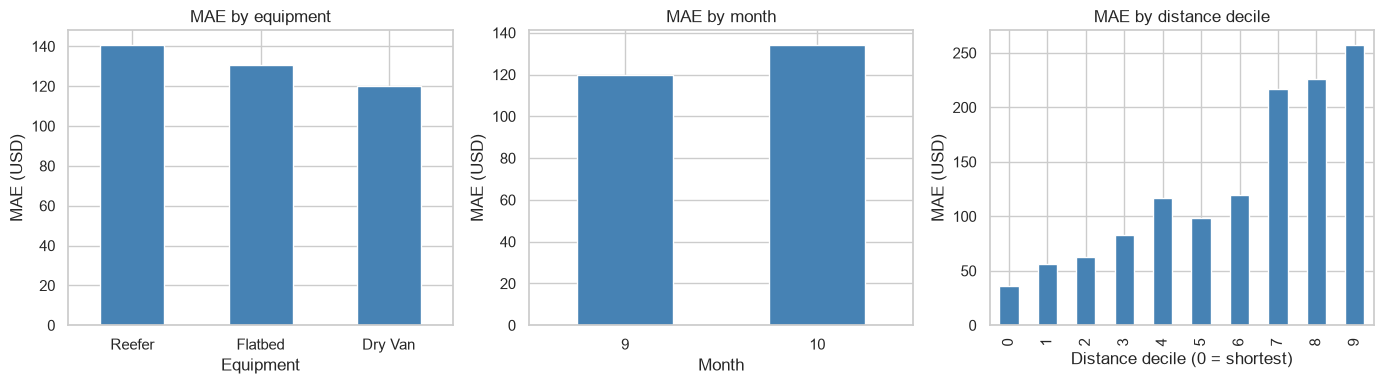

Top 20 worst errors:



,load_id,pickup,delivery,equipment,distance,weight,date,posted_rate,predicted_rate,abs_error
0,TR-040097,Baltimore,Oklahoma City,Reefer,"1,760.3000","29,521.0000",2025-09-11,"20,132.3700","3,884.4869","16,247.8831"
1,TR-040172,Montgomery,Fresno,Dry Van,"2,283.4000","32,447.0000",2025-09-11,"20,361.8900","4,396.2084","15,965.6816"
2,TR-043540,Milwaukee,Bakersfield,Dry Van,"1,893.0000","30,760.0000",2025-10-03,"17,514.1100","3,570.3556","13,943.7544"
3,TR-046214,Columbia,Tucson,Flatbed,"2,023.4000","34,710.0000",2025-10-20,"17,893.1700","4,048.3277","13,844.8423"
4,TR-047299,Boston,Bakersfield,Reefer,"2,979.1000","30,585.0000",2025-10-27,"19,110.3000","5,794.4193","13,315.8807"
5,TR-040323,Montgomery,El Paso,Dry Van,"1,639.9000","38,363.0000",2025-09-12,"14,949.2500","3,193.7606","11,755.4894"
6,TR-046517,Toledo,Albuquerque,Reefer,"1,684.3000","31,536.0000",2025-10-22,"14,784.3800","3,492.6884","11,291.6916"
7,TR-042882,San Antonio,Detroit,Dry Van,"1,460.5000","43,567.0000",2025-09-29,"13,503.6300","2,878.1444","10,625.4856"
8,TR-042150,Grand Rapids,Lubbock,Dry Van,"1,415.5000","35,333.0000",2025-09-24,"13,026.2200","2,834.9618","10,191.2582"
9,TR-046367,Bakersfield,Columbia,Dry Van,"2,251.9000","40,729.0000",2025-10-21,"14,403.1400","4,266.2357","10,136.9043"


In [53]:
error_df["distance_decile"] = pd.qcut(
    error_df["distance"], q=10, labels=False, duplicates="drop"
)

mae_by_equipment = (
    error_df.groupby("equipment")["abs_error"].mean().sort_values(ascending=False)
)
mae_by_month = error_df.groupby("month")["abs_error"].mean().sort_index()
mae_by_distance = error_df.groupby("distance_decile")["abs_error"].mean()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

mae_by_equipment.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_xlabel("Equipment")
axes[0].set_ylabel("MAE (USD)")
axes[0].set_title("MAE by equipment")
axes[0].tick_params(axis="x", rotation=0)

mae_by_month.plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("MAE (USD)")
axes[1].set_title("MAE by month")
axes[1].tick_params(axis="x", rotation=0)

mae_by_distance.plot(kind="bar", ax=axes[2], color="steelblue")
axes[2].set_xlabel("Distance decile (0 = shortest)")
axes[2].set_ylabel("MAE (USD)")
axes[2].set_title("MAE by distance decile")

plt.tight_layout()
plt.show()

worst_errors = (
    error_df.nlargest(20, "abs_error")[
        [
            "load_id",
            "pickup",
            "delivery",
            "equipment",
            "distance",
            "weight",
            "date",
            "posted_rate",
            "predicted_rate",
            "abs_error",
        ]
    ]
    .reset_index(drop=True)
)
print("Top 20 worst errors:\n")
worst_errors

In [54]:
best_errors = (
    error_df.nsmallest(10, "abs_error")[
        [
            "load_id",
            "pickup",
            "delivery",
            "equipment",
            "distance",
            "weight",
            "date",
            "posted_rate",
            "predicted_rate",
            "abs_error",
        ]
    ]
    .reset_index(drop=True)
)
print("Top 10 best predictions:\n")
best_errors

Top 10 best predictions:



,load_id,pickup,delivery,equipment,distance,weight,date,posted_rate,predicted_rate,abs_error
0,TR-038514,Albany,Amarillo,Reefer,"2,318.8000","23,512.0000",2025-09-01,"4,438.0400","4,438.0386",0.0014
1,TR-045233,Los Angeles,Fresno,Dry Van,429.3000,"20,715.0000",2025-10-14,944.7800,944.7928,0.0128
2,TR-038830,Louisville,Mobile,Dry Van,475.4000,"22,162.0000",2025-09-03,"1,045.1100","1,045.0858",0.0242
3,TR-040500,Corpus Christi,Atlanta,Flatbed,841.4000,"36,311.0000",2025-09-13,"2,027.0200","2,026.9928",0.0272
4,TR-039507,Baton Rouge,Toledo,Dry Van,"1,052.7000","38,607.0000",2025-09-07,"2,144.5500","2,144.5211",0.0289
5,TR-041453,Milwaukee,Detroit,Reefer,439.0000,"24,657.0000",2025-09-19,"1,067.1200","1,067.1586",0.0386
6,TR-042957,Tampa,Baltimore,Dry Van,"1,250.4000","26,155.0000",2025-09-29,"2,364.9400","2,364.9937",0.0537
7,TR-040449,Los Angeles,Grand Rapids,Dry Van,"2,316.5000","41,089.0000",2025-09-13,"4,194.5900","4,194.5362",0.0538
8,TR-047508,Tulsa,Baton Rouge,Dry Van,290.9000,"37,967.0000",2025-10-29,766.5600,766.6139,0.0539
9,TR-045635,Kansas City,Raleigh,Dry Van,925.7000,"38,737.0000",2025-10-16,"1,937.2400","1,937.3055",0.0655


**Observations**

- **Overall:** MAE **$127.22**, RMSE **$639.32** on Sep–Oct — matches model selection, confirming the Jan–Aug `analysis_model` setup.
- **Residual bias:** Mean residual **+$93** (median **+$40**) — model **underpredicts** more often than overpredicts (~79% of loads). Residuals are right-skewed: a few extreme high-rate loads drive RMSE well above MAE.
- **By equipment:** Reefer worst (**$141** MAE) → Flatbed (**$131**) → Dry Van (**$120**). Equipment premium loads are harder to nail.
- **By month:** September (**$120**) easier than October (**$134**) — slight temporal drift or harder Oct mix.
- **By distance:** MAE rises sharply on long hauls (**~$36** on shortest decile vs **~$258** on longest). Distance is easy at short range; very long lanes with extreme rates are the main failure mode.
- **Worst 20 errors:** All are **massive underpredictions** on long cross-country lanes with posted rates **$17k–$20k** while model predicts **$3.5k–$5.8k**. Mostly Dry Van (13/20). These outliers explain the fat residual tail — not a systematic bug, but rare premium loads the model hasn't seen enough of.
- **Best 10 predictions:** Errors under **$0.07** — essentially exact fits on moderate-rate loads ($766–$4,438) across short and long distances. Shows the model nails familiar lane/rate patterns; failures are driven by rare extremes, not typical freight.

## Submission predictions

Generate `validation_predictions.csv` (12k holdout loads) and fill `data/december_chart_inputs.csv` using `final_model`.

In [55]:
final_feature_stats = fit_preprocessing_stats(train_df, train_df)
train_full_feat = engineer_features(train_df, final_feature_stats)

final_model = make_pipeline(feature_cols, make_estimator(best_name), dense_output=True)
y_full = train_full_feat[TARGET]
if final_log_target:
    final_model.fit(train_full_feat[feature_cols], np.log1p(y_full))
else:
    final_model.fit(train_full_feat[feature_cols], y_full)

holdout_feat = engineer_features(val_df, final_feature_stats)
holdout_preds = predict_rate(final_model, holdout_feat, log_target=final_log_target)

validation_predictions = pd.DataFrame(
    {"load_id": val_df["load_id"], "predicted_rate": holdout_preds}
)

assert len(validation_predictions) == 12_000
assert validation_predictions["load_id"].is_unique
assert (validation_predictions["predicted_rate"] > 0).all()

validation_predictions.to_csv("../validation_predictions.csv", index=False)

december_submission = december_df.copy()
december_feat = engineer_features(december_submission, final_feature_stats)
december_submission["predicted_rate"] = predict_rate(
    final_model, december_feat, log_target=final_log_target
)

december_cols = [
    "pickup",
    "delivery",
    "distance",
    "equipment",
    "weight",
    "date",
    "predicted_rate",
]
december_submission[december_cols].to_csv(
    "../data/december_chart_inputs.csv", index=False
)

pd.DataFrame(
    {
        "file": ["validation_predictions.csv", "data/december_chart_inputs.csv"],
        "rows": [len(validation_predictions), len(december_submission)],
        "min_rate": [
            validation_predictions["predicted_rate"].min(),
            december_submission["predicted_rate"].min(),
        ],
        "mean_rate": [
            validation_predictions["predicted_rate"].mean(),
            december_submission["predicted_rate"].mean(),
        ],
        "max_rate": [
            validation_predictions["predicted_rate"].max(),
            december_submission["predicted_rate"].max(),
        ],
    }
).round(2)

,file,rows,min_rate,mean_rate,max_rate
0,validation_predictions.csv,12000,210.8900,"2,350.3600","6,456.5500"
1,data/december_chart_inputs.csv,31,849.9600,851.8700,853.3000


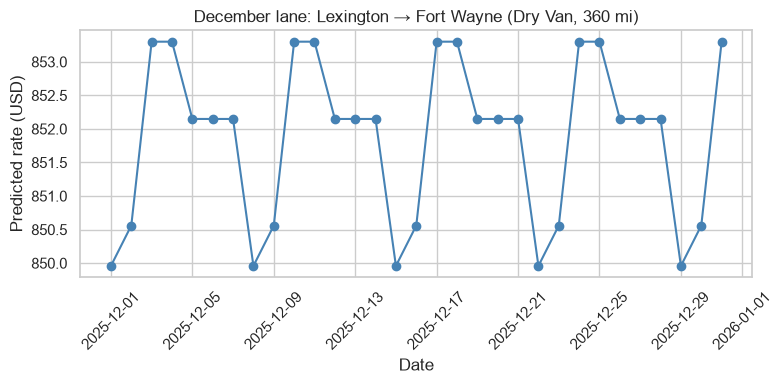

Run scorer:
python score.py --predictions validation_predictions.csv --december-predictions data/december_chart_inputs.csv


In [56]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    pd.to_datetime(december_submission["date"]),
    december_submission["predicted_rate"],
    marker="o",
    color="steelblue",
)
ax.set_xlabel("Date")
ax.set_ylabel("Predicted rate (USD)")
ax.set_title("December lane: Lexington → Fort Wayne (Dry Van, 360 mi)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(
    "Run scorer:\n"
    "python score.py "
    "--predictions validation_predictions.csv "
    "--december-predictions data/december_chart_inputs.csv"
)

**Observations**

- **Holdout (`validation_predictions.csv`):** 12,000 rows, all rates positive. Range **$211–$6,457**, mean **$2,350** — close to train mean (~$2,374), no obvious scale bug.
- **December (`december_chart_inputs.csv`):** 31 rows, range **$850–$853**, mean **$852** for Lexington → Fort Wayne Dry Van 360 mi. Nearly flat daily curve — expected because December rows lack real market signals (month 12 imputed to global median).
- **Sanity check:** December ~$2.36/mi is plausible for this lane; holdout max ~$6.5k is well below the $17k–$20k Sep–Oct outliers the model struggled with.
- Ran `python score.py --predictions validation_predictions.csv --december-predictions data/december_chart_inputs.csv` from repo root to validate and generate `scorer_results/candidate_december.png` for the report.